# LeetCode #540: Single Element in a Sorted Array

https://leetcode.com/problems/single-element-in-a-sorted-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (XOR scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search on Parity ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (XOR scan)
XOR all elements together; duplicates cancel out leaving the single element. Correct but $O(n)$ — visits every element.

### Optimal: Binary Search on Parity ★
Before the single element, each pair starts at an even index (pairs at indices 0-1, 2-3, …). After it, pairs start at odd indices. Round mid down to an even index: if `nums[mid] == nums[mid+1]`, the single is to the right (set `lo = mid + 2`); otherwise it's at `mid` or to the left (set `hi = mid`). Loop halves the range each step.

**Constraints:**
* 1 <= nums.length <= 10^5
* 0 <= nums[i] <= 10^5
* Every element appears exactly twice except for one
* nums is sorted in non-decreasing order


## Solutions

### C#

In [ ]:
public int SingleNonDuplicate(int[] nums) {
    int lo = 0, hi = nums.Length - 1;
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Round down to even: pair starts must be at even indices before the singleton
        if (mid % 2 == 1) mid--;
        // If pair is intact, singleton is to the right
        if (nums[mid] == nums[mid + 1]) lo = mid + 2;
        else hi = mid;  // Pair broken — singleton is here or to the left
    }
    return nums[lo];
}


### Python

In [ ]:
def singleNonDuplicate(self, nums: list[int]) -> int:
    lo, hi = 0, len(nums) - 1
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Round down to even: pair starts must be at even indices before the singleton
        if mid % 2 == 1:
            mid -= 1
        # If pair is intact, singleton is to the right
        if nums[mid] == nums[mid + 1]:
            lo = mid + 2
        else:
            hi = mid  # Pair broken — singleton is here or to the left
    return nums[lo]


### Go

In [ ]:
func singleNonDuplicate(nums []int) int {
    lo, hi := 0, len(nums)-1
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Round down to even: pair starts must be at even indices before the singleton
        if mid%2 == 1 { mid-- }
        // If pair is intact, singleton is to the right
        if nums[mid] == nums[mid+1] {
            lo = mid + 2
        } else {
            hi = mid  // Pair broken — singleton is here or to the left
        }
    }
    return nums[lo]
}


### Rust

In [ ]:
pub fn single_non_duplicate(nums: Vec<i32>) -> i32 {
    let (mut lo, mut hi) = (0usize, nums.len() - 1);
    while lo < hi {
        let mut mid = lo + (hi - lo) / 2;
        // Round down to even: pair starts must be at even indices before the singleton
        if mid % 2 == 1 { mid -= 1; }
        // If pair is intact, singleton is to the right
        if nums[mid] == nums[mid + 1] {
            lo = mid + 2;
        } else {
            hi = mid;  // Pair broken — singleton is here or to the left
        }
    }
    nums[lo]
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 1, 2, 3, 3, 4, 4, 8, 8]
lo=0,hi=8. mid=4→even. nums[4]=3≠nums[5]=4 → hi=4. mid=2→even. nums[2]=2≠nums[3]=3 → hi=2. lo=hi=2 → return nums[2]=2. Single element 2 at index 2.

**2. Slightly Complex**
**Input:** nums = [3, 3, 7, 7, 10, 11, 11]
lo=0,hi=6. mid=3→odd→mid=2. nums[2]=7=nums[3]=7 → lo=4. mid=5→odd→mid=4. nums[4]=10≠nums[5]=11 → hi=4. lo=hi=4 → return nums[4]=10.

**3. Edge Case: Time Factor**
**Input:** nums = [1,1,2,2,...,49999,49999,50000] (n=99999, singleton at end)
Each step: mid lands even and matches its pair → lo jumps right. After $\lceil \log_2(99999/2) \rceil \approx 16$ steps lo converges to index 99998. Worst-case depth for rightmost singleton.

**4. Edge Case: Space Factor**
**Input:** nums = [1]
lo=hi=0. Loop never enters. Return nums[0]=1. $O(1)$ space: only lo, hi, mid (three integers).

**5. Almost-Impossible but Plausible**
**Input:** nums = [0, 0, 1, 1, ..., 49999, 49999, 100000] (singleton 100000 at last index)
Exactly the edge-case time scenario with max value 10^5. mid always even, pairs always intact → lo jumps forward. No off-by-one: after `lo=mid+2` we always land on an even index, maintaining parity invariant. Returns 100000 correctly in $O(\log n)$.


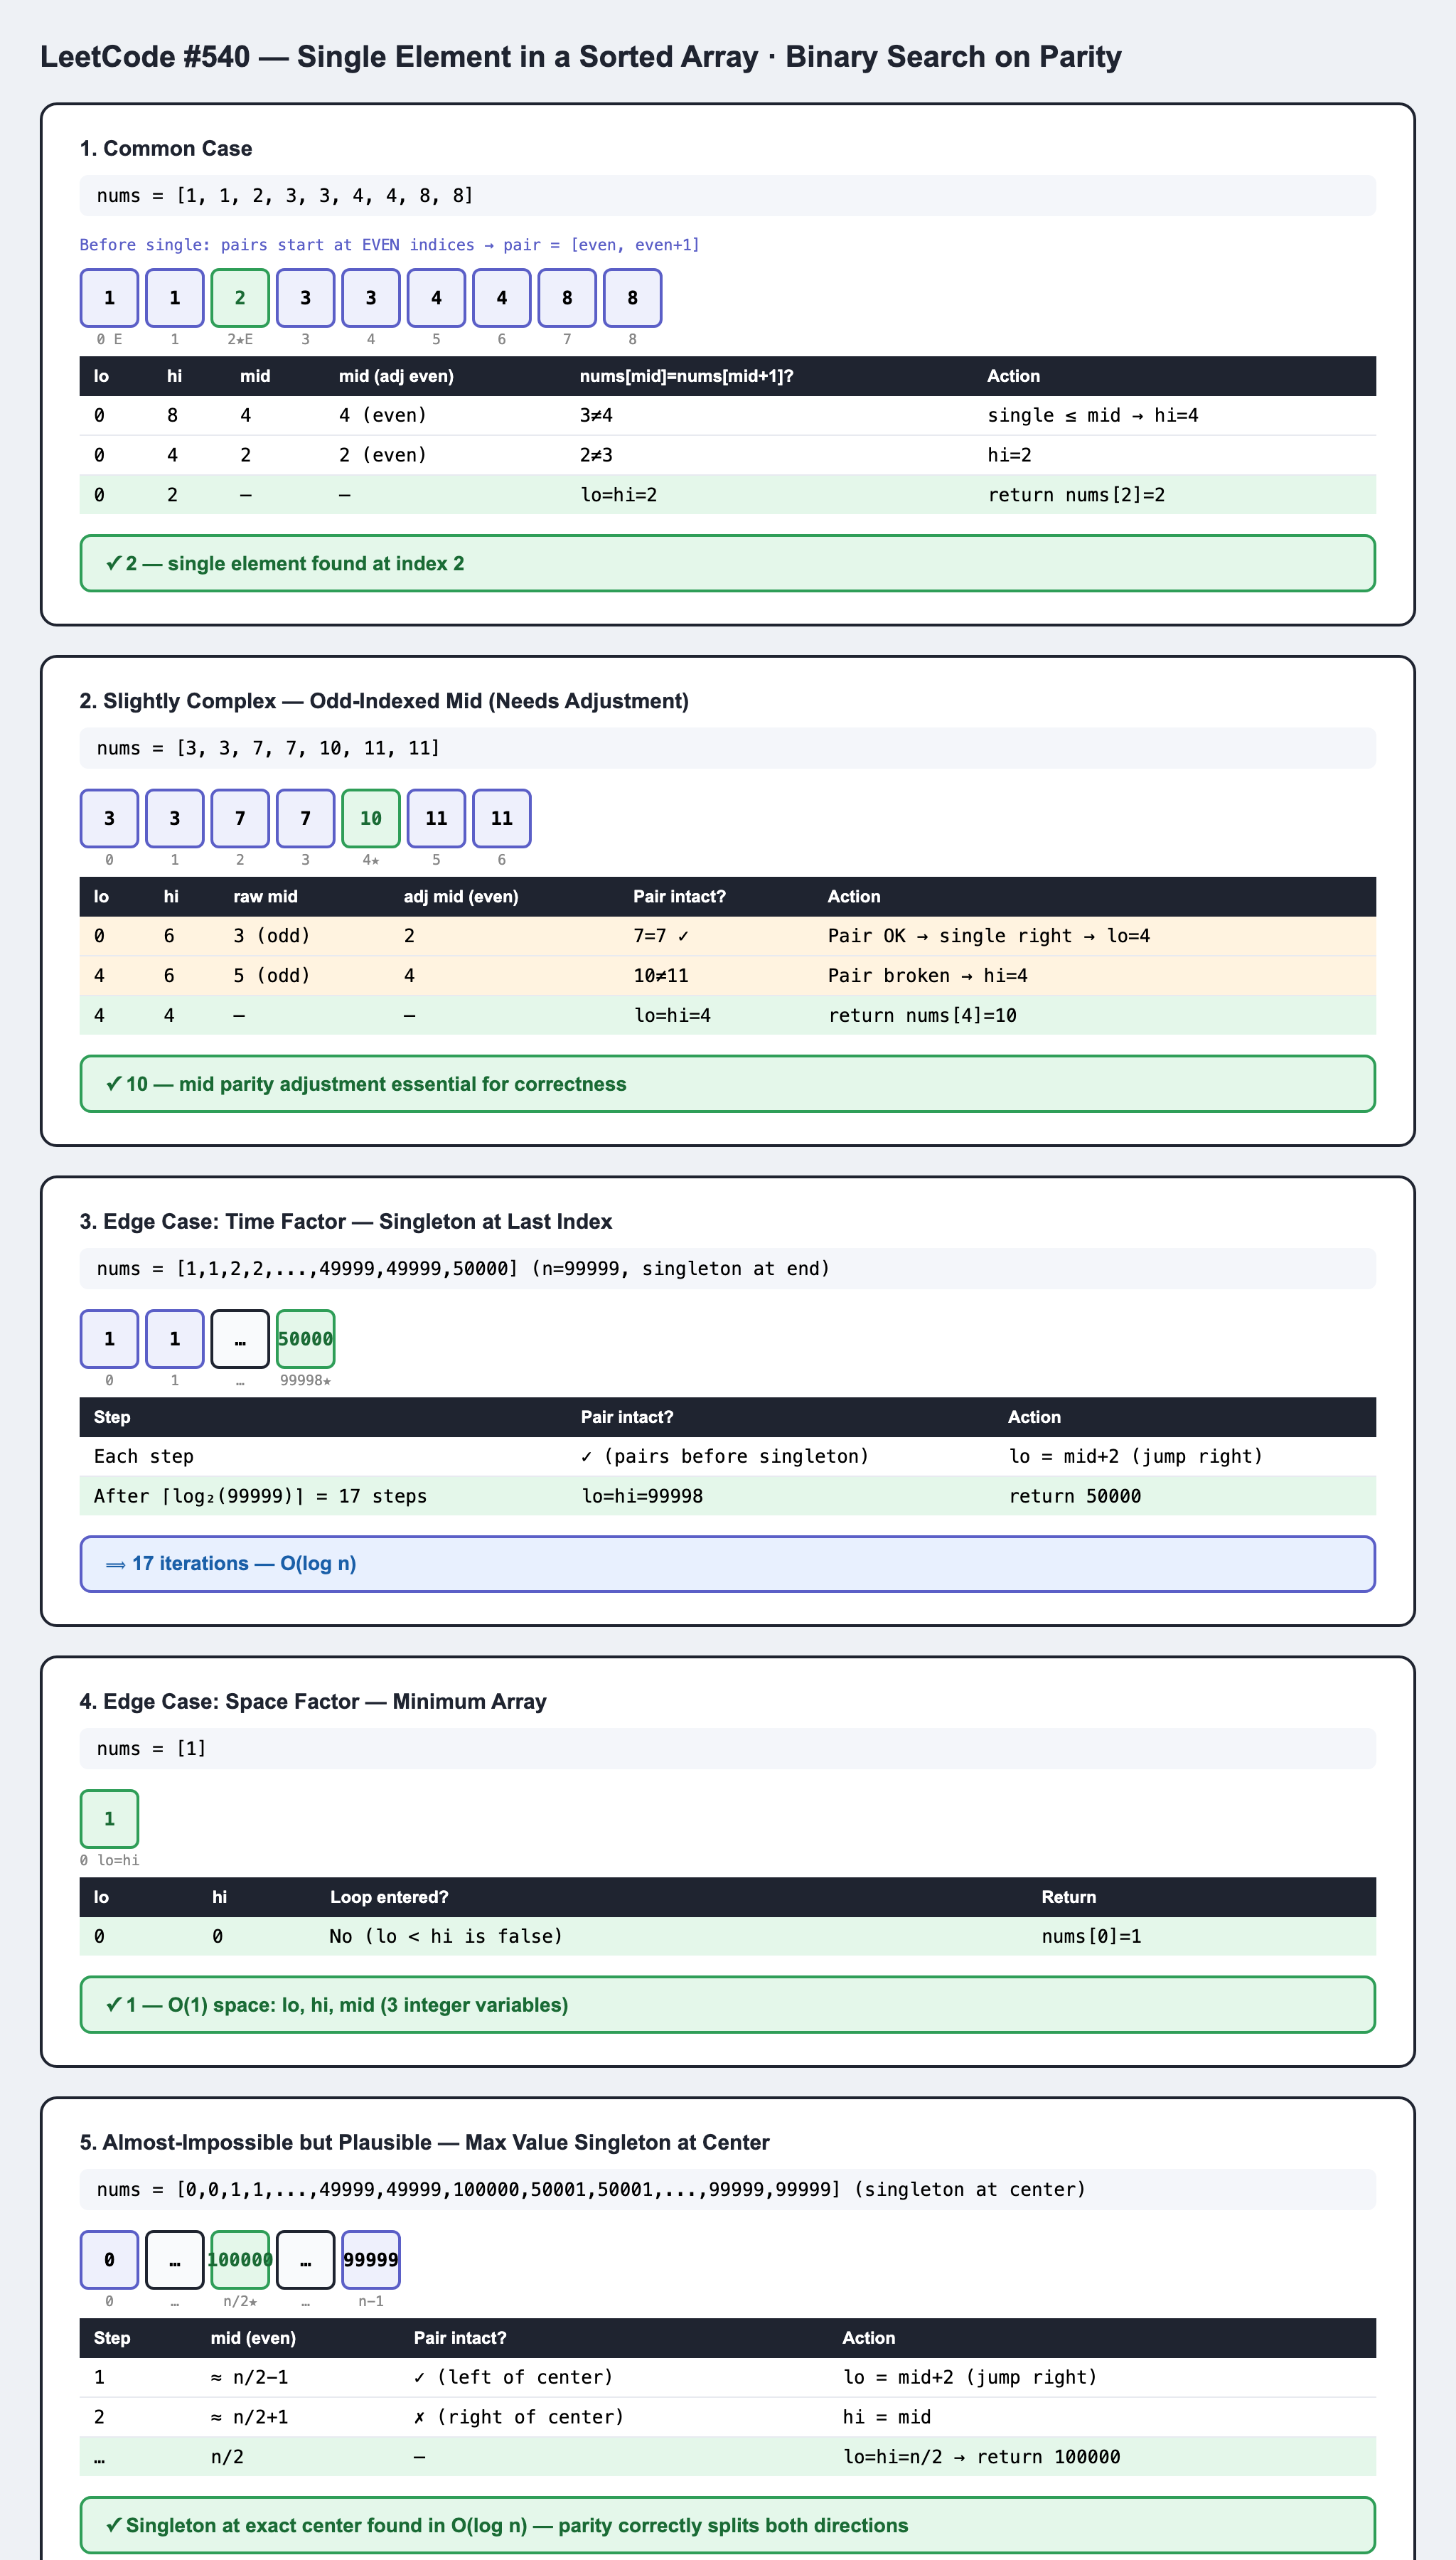